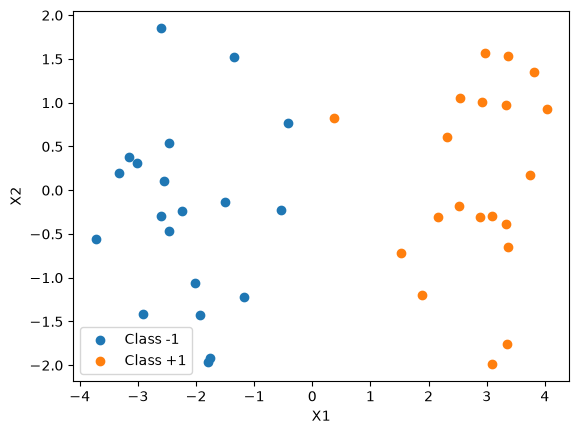

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 第一类
X1 = np.random.randn(20, 2) + [-2, 0]

# 第二类
X2 = np.random.randn(20, 2) + [3, 0]

X = np.vstack([X1, X2])
y = np.hstack([-np.ones(20), np.ones(20)])

plt.scatter(X1[:, 0], X1[:, 1], label="Class -1")
plt.scatter(X2[:, 0], X2[:, 1], label="Class +1")

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [17]:
from sklearn.svm import SVC

model = SVC(kernel="linear", C=1000)
#线性SVM，C越大，分类错误越不能接受，越接近硬间隔

model.fit(X, y)

print("支持向量数量：", len(model.support_))
print("支持向量：")
print(model.support_vectors_)

支持向量数量： 2
支持向量：
[[-0.42078718  0.76743473]
 [ 0.3802549   0.8219025 ]]


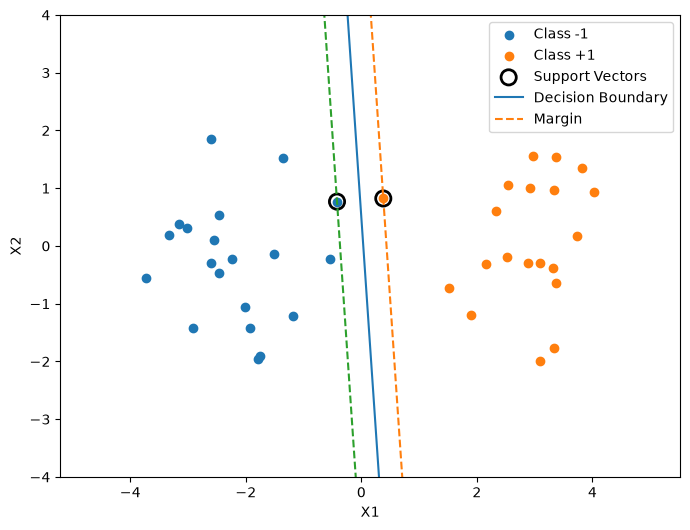

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X1[:, 0],
    X1[:, 1],
    label="Class -1"
)

plt.scatter(
    X2[:, 0],
    X2[:, 1],
    label="Class +1"
)


# =========================
# 4. 标出支持向量
# =========================

plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)


# =========================
# 5. 决策边界
# =========================

w = model.coef_[0]
b = model.intercept_[0]

x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

xx = np.linspace(x_min, x_max, 200)

# w1*x1 + w2*x2 + b = 0
yy = -(w[0] * xx + b) / w[1]


# =========================
# 6. 两条 Margin
# =========================

# SVM 的两条间隔边界：
#
# w1*x1 + w2*x2 + b = +1
# w1*x1 + w2*x2 + b = -1

yy_upper = -(w[0] * xx + b - 1) / w[1]
yy_lower = -(w[0] * xx + b + 1) / w[1]


# =========================
# 7. 绘制
# =========================

plt.plot(
    xx,
    yy,
    label="Decision Boundary"
)

plt.plot(
    xx,
    yy_upper,
    "--",
    label="Margin"
)

plt.plot(
    xx,
    yy_lower,
    "--"
)


plt.xlabel("X1")
plt.ylabel("X2")

plt.legend()
plt.ylim(-4,4)

plt.show()

SVM 对特征尺度敏感。（本例中X1，X2尺寸量级相同，不考虑特征缩放）
硬间隔：不允许有分类出错（模型泛化性能低），间隔小。
用参数C控制，C越大，分类越严格。

In [19]:
X_outlier = np.array([[0, 0]])
y_outlier = np.array([1])

X_soft = np.vstack([X, X_outlier])
y_soft = np.hstack([y, y_outlier])

In [20]:
model_soft = SVC(kernel="linear", C=1)

model_soft.fit(X_soft, y_soft)

print("支持向量数量：", len(model_soft.support_))

支持向量数量： 4


软间隔：允许少数样本进入间隔，甚至允许少量分类错误，但要付出惩罚。
正则化：控制模型复杂度、防止过拟合的思想（软间隔即包含了正则化的思想，平衡模型泛化性能与分类精确度）

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

np.random.seed(7)

# 第一类
X_neg = np.random.randn(25, 2) * 0.55 + [-2, -2]

# 第二类
X_pos = np.random.randn(25, 2) * 0.55 + [2, 2]

X = np.vstack([X_neg, X_pos])
y = np.hstack([
    -np.ones(25),
    np.ones(25)
])

# 故意加入一个“麻烦点”
# 它属于 +1 类，但位置靠近 -1 类
X = np.vstack([X, [-1, -1]])
y = np.hstack([y, 1])

print("数据形状：", X.shape)

数据形状： (51, 2)


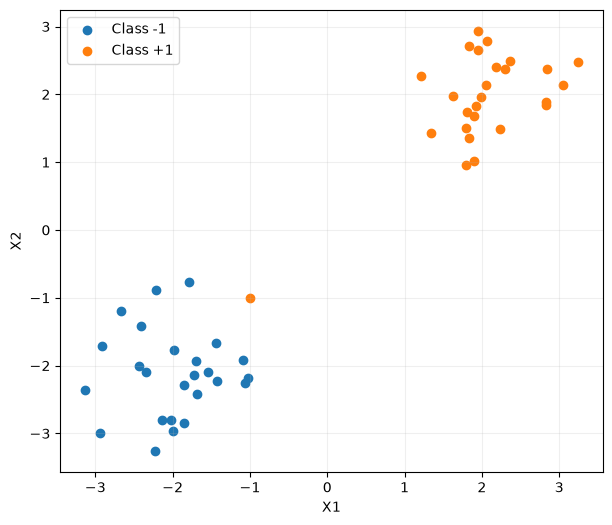

In [9]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    label="Class -1"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class +1"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

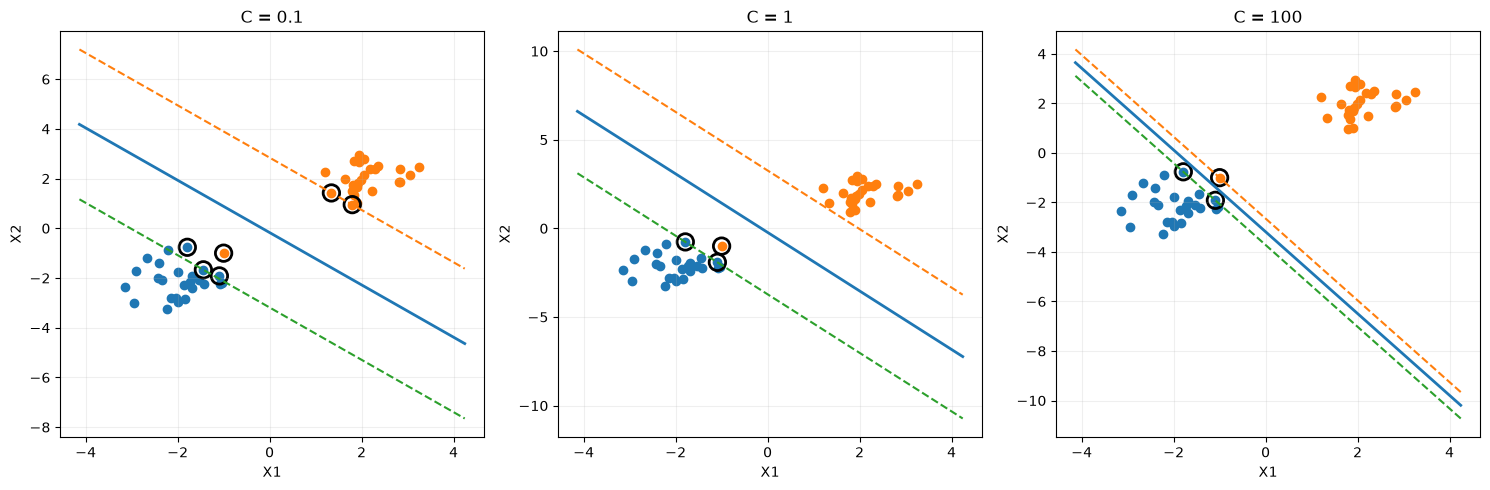

In [10]:
C_values = [0.1, 1, 100]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, C in zip(axes, C_values):

    model = SVC(kernel="linear", C=C)
    model.fit(X, y)

    w = model.coef_[0]
    b = model.intercept_[0]

    xx = np.linspace(
        X[:, 0].min() - 1,
        X[:, 0].max() + 1,
        300
    )

    # 决策边界：
    # w1*x1 + w2*x2 + b = 0
    yy = -(w[0] * xx + b) / w[1]

    # 两条 Margin：
    # w1*x1 + w2*x2 + b = ±1
    yy_upper = -(w[0] * xx + b - 1) / w[1]
    yy_lower = -(w[0] * xx + b + 1) / w[1]

    # 数据
    ax.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        label="Class -1"
    )

    ax.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class +1"
    )

    # 支持向量
    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=140,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Support Vector"
    )

    # 决策边界
    ax.plot(xx, yy, linewidth=2)

    # Margin
    ax.plot(xx, yy_upper, "--")
    ax.plot(xx, yy_lower, "--")

    ax.set_title(f"C = {C}")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

二.核方法
解决无法用线性SVM解决的数据集分类

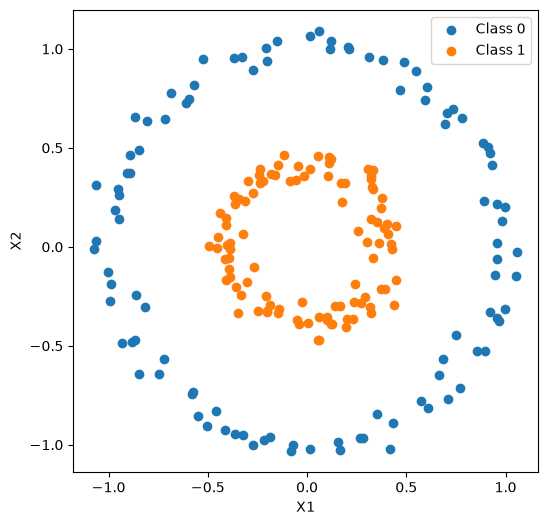

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=200,
    factor=0.4,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.axis("equal")

plt.show()

1.线性SVM：无法正确分类

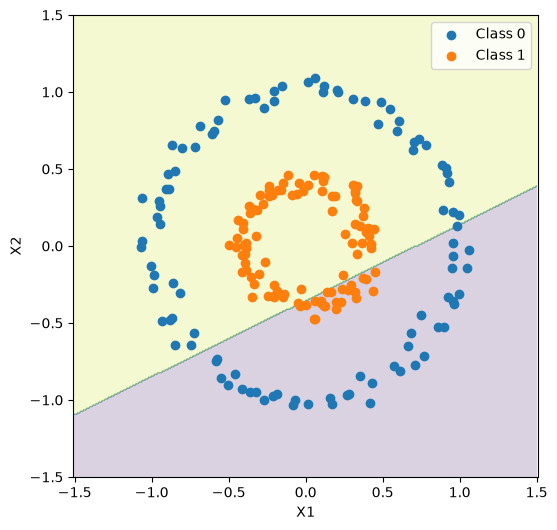

In [23]:
kernel="linear"

from sklearn.svm import SVC

model_linear = SVC(
    kernel="linear",
    C=1
)

model_linear.fit(X, y)
xx, yy = np.meshgrid(
    np.linspace(-1.5, 1.5, 300),
    np.linspace(-1.5, 1.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model_linear.predict(grid)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.axis("equal")

plt.show()

2.对于圆形数据，常用：RBF核

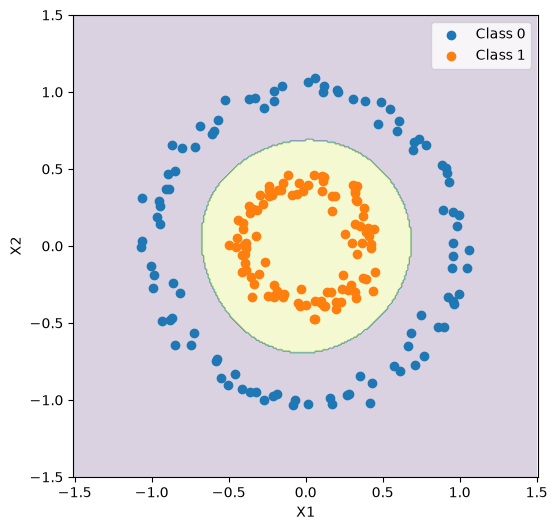

In [25]:
model_rbf = SVC(
    kernel="rbf",
    C=1
)#选择RBF核

model_rbf.fit(X, y)

Z = model_rbf.predict(grid)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.axis("equal")

plt.show()

In [ ]:
3.用同一份数据，对比线性核linear、多项式核poly，高斯核RBF

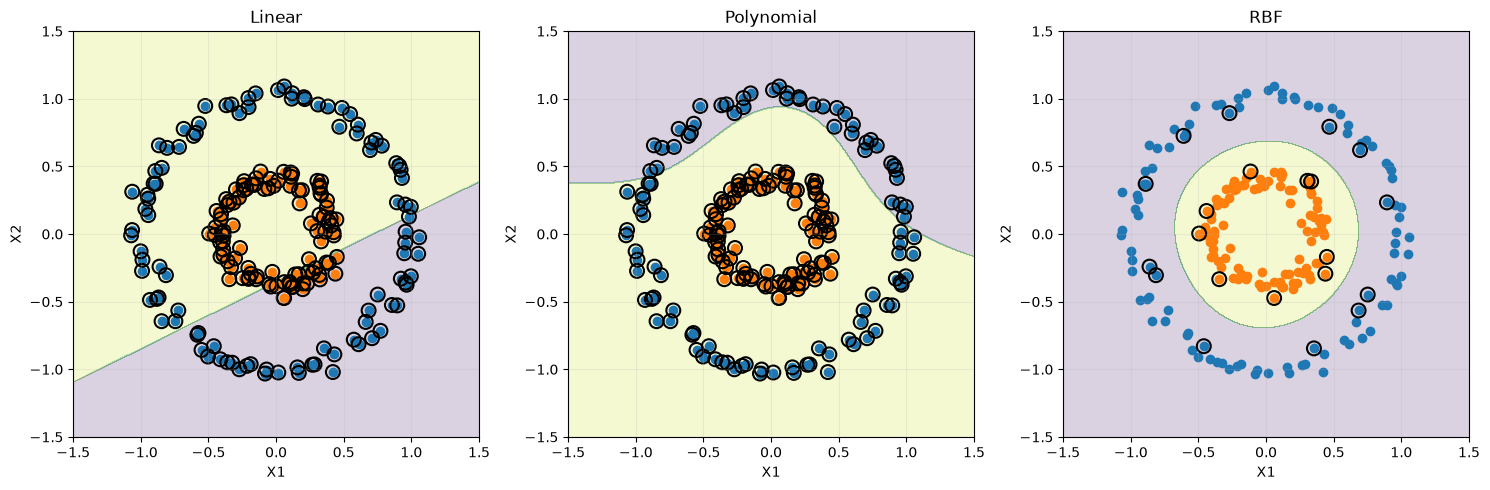

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# ==================================
# 1. 生成同一份数据
# ==================================

X, y = make_circles(
    n_samples=200,
    factor=0.4,
    noise=0.05,
    random_state=42
)


# ==================================
# 2. 建立三个 SVM
# ==================================

models = {
    "Linear": SVC(kernel="linear", C=1),
    "Polynomial": SVC(kernel="poly", C=1, degree=3),
    "RBF": SVC(kernel="rbf", C=1, gamma="scale")
}#C控制间隔严格程度，1为正常，poly中的degree=3指用的是三次多项式核，rbf中的gamma用于控制rbf决策边界的“灵活程度”


# ==================================
# 3. 创建网格
# ==================================

xx, yy = np.meshgrid(
    np.linspace(-1.5, 1.5, 400),
    np.linspace(-1.5, 1.5, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# ==================================
# 4. 绘制三个模型
# ==================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

for ax, (name, model) in zip(axes, models.items()):

    # 训练
    model.fit(X, y)

    # 预测整个网格
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # 分类区域
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.2
    )

    # 数据点
    ax.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0"
    )

    ax.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1"
    )

    # 支持向量
    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=100,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Support Vectors"
    )

    ax.set_title(name)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

C参数：控制对分类错误的惩罚，C越小，正则化强，越可能欠拟合，C越大，越接近硬间隔，越可能过拟合。
gamma参数：gamma越小，边界越平滑，越可能欠拟合、gamma越大，边界更灵活，越可能过拟合。

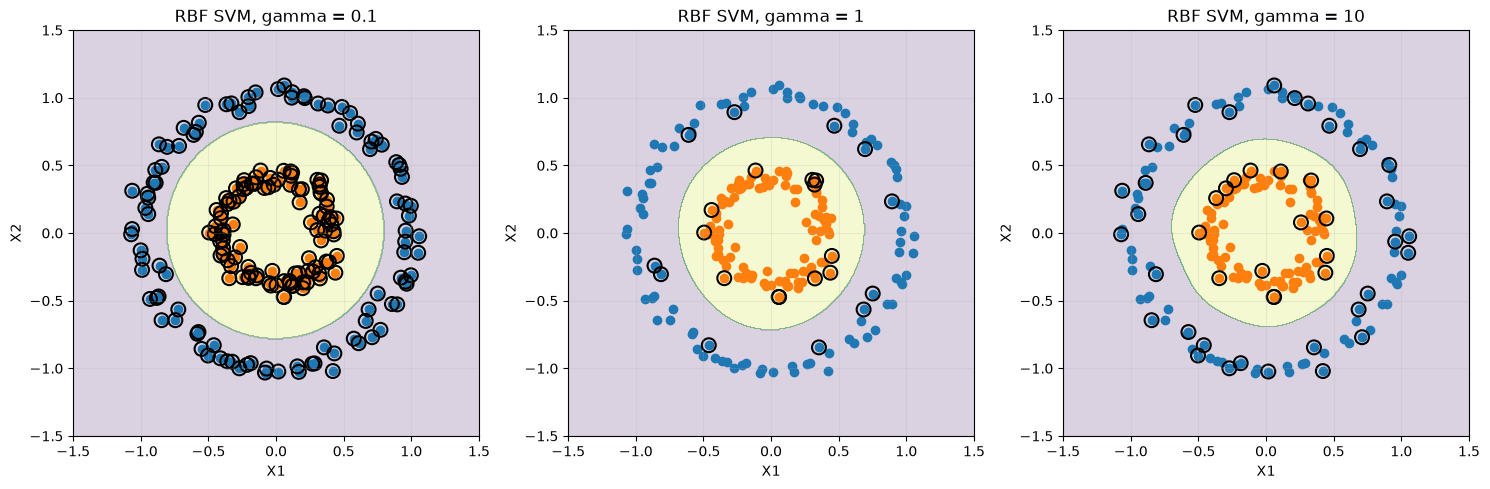

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# ==================================
# 1. 生成数据
# ==================================

X, y = make_circles(
    n_samples=200,
    factor=0.4,
    noise=0.05,
    random_state=42
)

# ==================================
# 2. gamma 的三个取值
# ==================================

gamma_values = [0.1, 1, 10]

# ==================================
# 3. 创建网格
# ==================================

xx, yy = np.meshgrid(
    np.linspace(-1.5, 1.5, 400),
    np.linspace(-1.5, 1.5, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# ==================================
# 4. 绘制三个模型
# ==================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

for ax, gamma in zip(axes, gamma_values):

    # RBF SVM
    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )

    model.fit(X, y)

    # 预测网格
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # 分类区域
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.2
    )

    # 数据点
    ax.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0"
    )

    ax.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1"
    )

    # 支持向量
    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=100,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5
    )

    ax.set_title(f"RBF SVM, gamma = {gamma}")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

三.支持向量回归SVR：目标：找到一条回归函数，使大部分样本落在一个宽度为 2ϵ 的“管道”里面。
ε-不敏感管道：管道内的点认为不产生损失，管道外的点接入惩罚。

1生成非线性数据

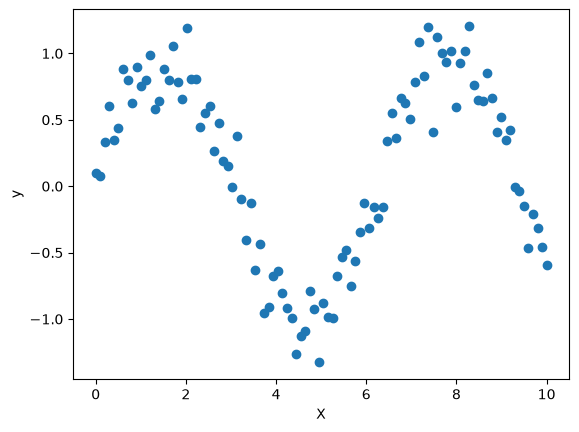

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(0, 10, 100)

y = np.sin(X) + np.random.normal(0, 0.2, 100)

X = X.reshape(-1, 1)

plt.scatter(X, y)

plt.xlabel("X")
plt.ylabel("y")

plt.show()

建立线性SVR回归模型

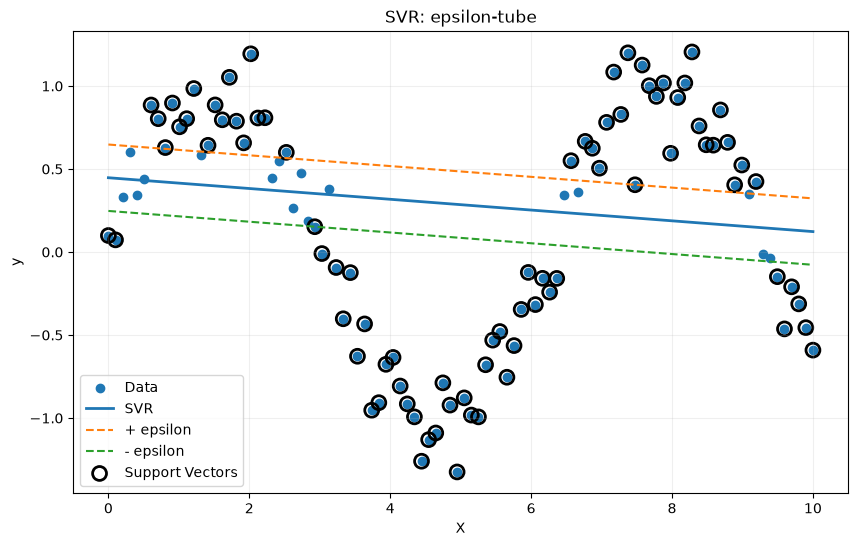

In [30]:
from sklearn.svm import SVR

# 创建 SVR
model = SVR(
    kernel="linear",
    C=10,
    epsilon=0.2
)

# 训练
model.fit(X, y)

# 预测
y_pred = model.predict(X)

# 获取支持向量
support_X = X[model.support_]
support_y = y[model.support_]

# 计算 epsilon 管道
epsilon = 0.2

y_upper = y_pred + epsilon
y_lower = y_pred - epsilon


# ==========================
# 绘图
# ==========================

plt.figure(figsize=(10, 6))

# 原始数据
plt.scatter(
    X,
    y,
    label="Data"
)

# 回归线
plt.plot(
    X,
    y_pred,
    linewidth=2,
    label="SVR"
)

# epsilon 管道
plt.plot(
    X,
    y_upper,
    "--",
    label="+ epsilon"
)

plt.plot(
    X,
    y_lower,
    "--",
    label="- epsilon"
)

# 支持向量
plt.scatter(
    support_X,
    support_y,
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("SVR: epsilon-tube")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

3.改变ε：ε越大，管道越宽。

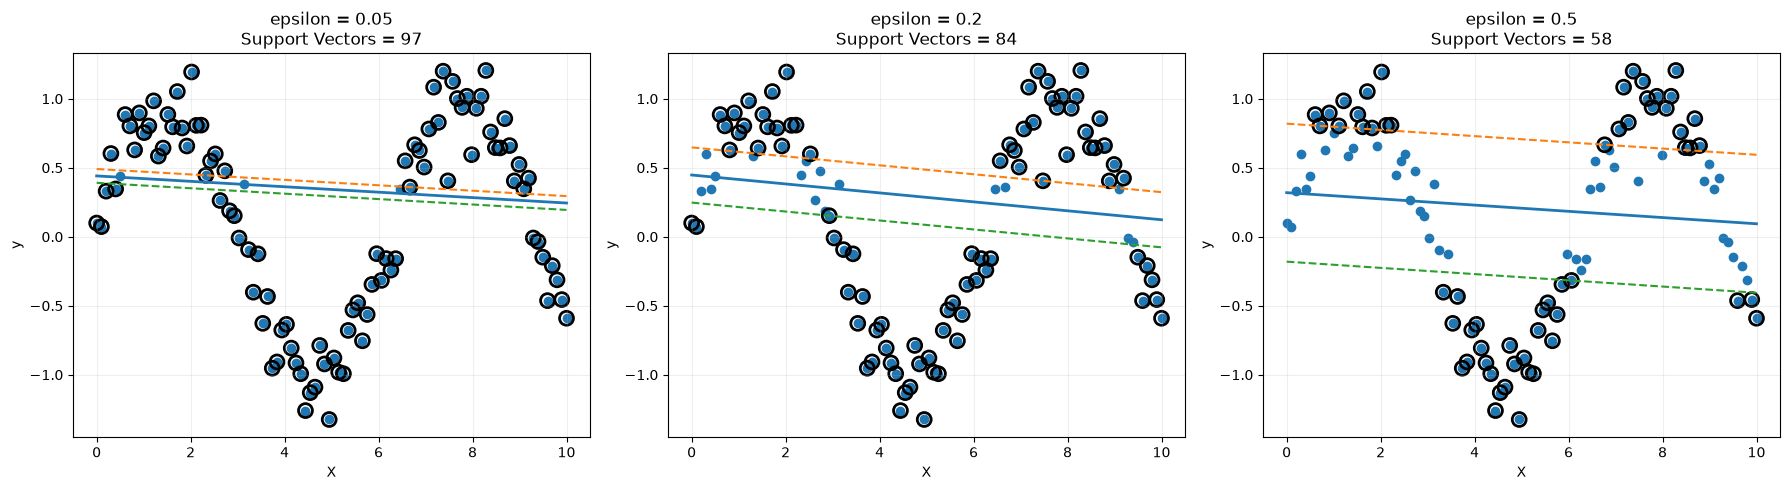

In [33]:
from sklearn.svm import SVR

epsilon_values = [0.05, 0.2, 0.5]

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

for ax, epsilon in zip(axes, epsilon_values):

    # 创建模型
    model = SVR(
        kernel="linear",
        C=10,
        epsilon=epsilon
    )

    # 训练
    model.fit(X, y)

    # 预测
    y_pred = model.predict(X)

    # epsilon 管道
    y_upper = y_pred + epsilon
    y_lower = y_pred - epsilon

    # 数据
    ax.scatter(
        X,
        y,
        label="Data"
    )

    # 回归线
    ax.plot(
        X,
        y_pred,
        linewidth=2,
        label="SVR"
    )

    # 上下管道
    ax.plot(
        X,
        y_upper,
        "--",
        label="+ epsilon"
    )

    ax.plot(
        X,
        y_lower,
        "--",
        label="- epsilon"
    )

    # 支持向量的真实坐标
    support_X = X[model.support_]
    support_y = y[model.support_]

    ax.scatter(
        support_X,
        support_y,
        s=100,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Support Vectors"
    )

    ax.set_title(
        f"epsilon = {epsilon}\n"
        f"Support Vectors = {len(model.support_)}"
    )

    ax.set_xlabel("X")
    ax.set_ylabel("y")

    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
结合SVR与核方法：采用rbf核

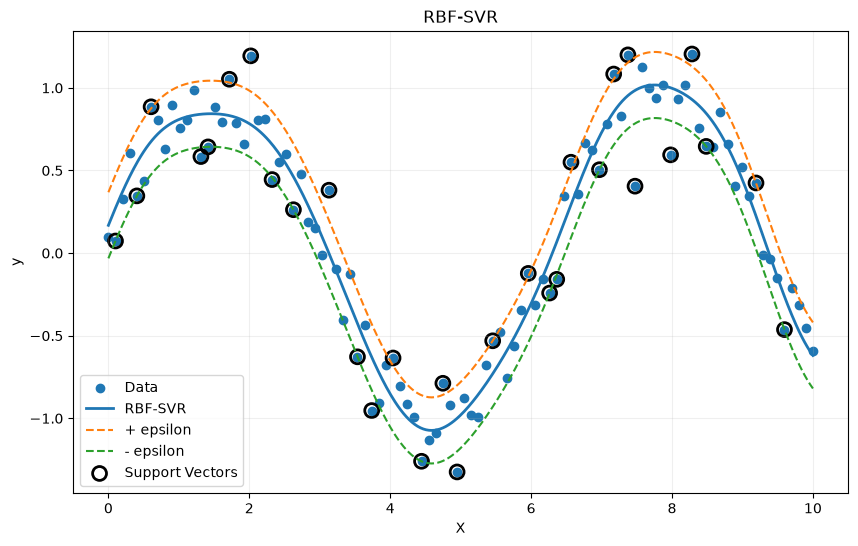

支持向量数量： 30


In [32]:
from sklearn.svm import SVR

model_rbf = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.2,
    gamma=0.5
)

# 训练
model_rbf.fit(X, y)

# 为了让曲线更平滑，
# 重新生成更密集的 X
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

# 预测
y_plot = model_rbf.predict(X_plot)

# 原始数据的预测
y_pred = model_rbf.predict(X)

# epsilon 管道
epsilon = 0.2

y_upper = y_plot + epsilon
y_lower = y_plot - epsilon


# ==========================
# 绘图
# ==========================

plt.figure(figsize=(10, 6))

# 原始数据
plt.scatter(
    X,
    y,
    label="Data"
)

# RBF-SVR
plt.plot(
    X_plot,
    y_plot,
    linewidth=2,
    label="RBF-SVR"
)

# epsilon 管道
plt.plot(
    X_plot,
    y_upper,
    "--",
    label="+ epsilon"
)

plt.plot(
    X_plot,
    y_lower,
    "--",
    label="- epsilon"
)

# 支持向量
support_X = X[model_rbf.support_]
support_y = y[model_rbf.support_]

plt.scatter(
    support_X,
    support_y,
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("X")
plt.ylabel("y")

plt.title("RBF-SVR")

plt.legend()
plt.grid(alpha=0.2)

plt.show()


print("支持向量数量：", len(model_rbf.support_))